In [1]:
import os
import leafmap
from datetime import date
from d2spy.workspace import Workspace
from plot_extraction import PlotExtraction
import matplotlib.pyplot as plt

In [2]:
# Connect to workspace
workspace = Workspace.connect("https://ps2.d2s.org", "kim4012@purdue.edu")

In [3]:
# Change the search term in `.filter_by_title` to match your project
project = workspace.get_projects().filter_by_title("cornell")[2]
print(project)

Project(title='Cornell Wheat - 2022', description='T3<->UASHUB')


In [4]:
# Change the date range in `filter_by_date` to match the acquistion date of the flight in your project
flight = project.get_flights().filter_by_date(date(2022, 5, 11), date(2022, 5, 11))[0]
print(flight)

Flight(acquisition_date='2022-05-11', name=None, altitude=120.0, side_overlap=60.0, forward_overlap=75.0, sensor='RGB', platform='Phantom_4')


In [5]:
# Change the search term in `.filter_by_data_type` to match your COG's data type
data_product = flight.get_data_products().filter_by_data_type("ortho")[0]
print(data_product)

DataProduct(data_type='ortho', filepath='/static/projects/b4ab960b-9629-46d7-881c-5612fd5ee0dd/flights/0d73f050-6a66-4922-851c-9b98e2a45dab/data_products/58822a09-c290-41ac-8248-a306fe5299cf/7c782101-90a6-42a5-b39f-c5b70d0cfb4a.tif', original_filename='20220511_cn_mic_dry_mosaic_rgb.tif', is_active=True, public=True, stac_properties={'raster': [{'data_type': 'uint8', 'stats': {'minimum': 0.0, 'maximum': 255.0, 'mean': 112.381, 'stddev': 89.018}}, {'data_type': 'uint8', 'stats': {'minimum': 0.0, 'maximum': 255.0, 'mean': 115.057, 'stddev': 66.764}}, {'data_type': 'uint8', 'stats': {'minimum': 0.0, 'maximum': 255.0, 'mean': 73.811, 'stddev': 57.792}}, {'data_type': 'uint8', 'stats': {'minimum': 0.0, 'maximum': 255.0, 'mean': 93.907, 'stddev': 122.995}}], 'eo': [{'name': 'b1', 'description': 'Red'}, {'name': 'b2', 'description': 'Green'}, {'name': 'b3', 'description': 'Blue'}, {'name': 'b4', 'description': 'Alpha'}]}, status='SUCCESS', url='https://ps2.d2s.org/static/projects/b4ab960b-962

In [6]:
if workspace.api_key:
    os.environ["D2S_API_KEY"] = workspace.api_key
else:
    # Note, you will need to log in again to fetch the key from workspace.api_key or you can manually enter the key above
    print("Please create an API key from your D2S Profile page")

In [7]:
plot = PlotExtraction(data_product)

In [9]:
os.environ["TITILER_ENDPOINT"] = "https://tt.d2s.org"

m = leafmap.Map()
m.add_cog_layer(data_product.url, name="ortho", zoom_to_layer=True)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [12]:
out_filename = "./clipped_cog.tif"
# plot.clip(m.draw_control.last_draw, out_filename)

In [13]:
plot.load_image(out_filename)

In [24]:
sam_checkpoint = "/home/hans/projects/segment-anything/checkpoint/sam_vit_h_4b8939.pth"
plot.load_sam(sam_checkpoint, points_per_side=64)

Loaded device: cuda


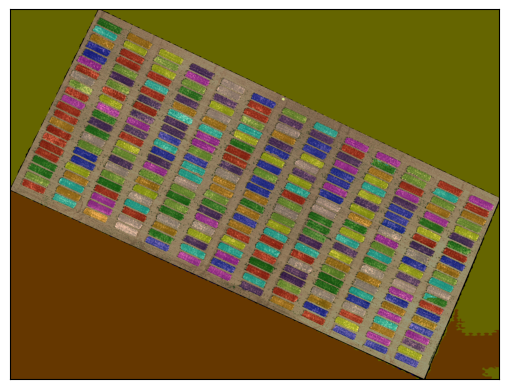

In [25]:
masks = plot.get_masks(resize=1024)

from skimage.color import label2rgb

plt.imshow(plot.img_array)
plt.imshow(label2rgb(masks), alpha=0.4)
plt.xticks([])
plt.yticks([])
plt.show()

Estimated orientation angle: 24.98 degree


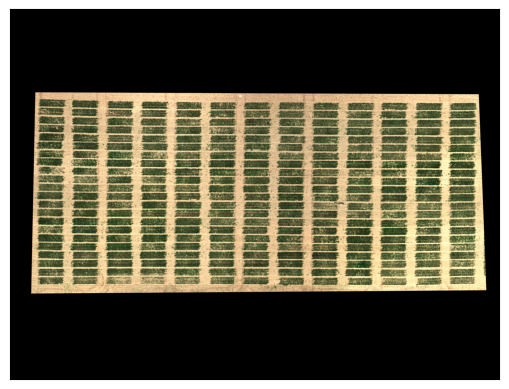

In [26]:
img_rotated = plot.rotate_plot(offset=180)

plt.imshow(img_rotated)
plt.xticks([])
plt.yticks([])
plt.show()

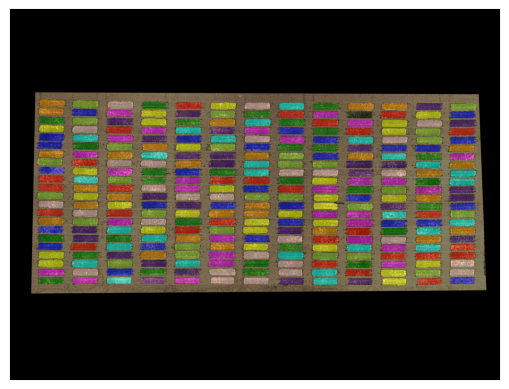

In [27]:
filtered_mask = plot.filter_plots(plot_width=4, plot_height=1, delta_area=1)

plt.imshow(img_rotated)
plt.imshow(label2rgb(filtered_mask), alpha=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

In [28]:
gdf_local = plot.get_polygons()
gdf_geojson = plot.to_geojson(gdf_local, rotation=True)

In [29]:
m.clear_layers()
m.add_cog_layer(data_product.url, name="ortho")
m.add_geojson(gdf_geojson, layer_name="Initial plot boundary", style={"color": "red", "weight": 1, "fill": False}, zoom_to_layer=True)
m

Map(bottom=198396947.0, center=[42.446400444743546, -76.43965646624565], controls=(ZoomControl(options=['posit…

In [30]:
gdf_filled = plot.grid_filling(n_rows=22, n_cols=13)
gdf_geojson = plot.to_geojson(gdf_filled, rotation=True)

In [31]:
m.clear_layers()
m.add_cog_layer(data_product.url, name="ortho")
m.add_geojson(gdf_geojson, layer_name="Initial plot boundary", style={"color": "red", "weight": 1, "fill": False}, zoom_to_layer=True)
m

Map(bottom=99198698.0, center=[42.44632671852316, -76.43951430916786], controls=(ZoomControl(options=['positio…

In [32]:
gdf_warped = gdf_filled.to_crs('EPSG:32618')
gdf_removed = plot.grid_remove(gdf_warped, dist_thr=1, dist_thr2=1, cc_coverage_thr=0.2)
gdf_final = plot.assign_row_col(gdf_removed, dist_thr = 1)
gdf_geojson = plot.to_geojson(gdf_final, rotation=True)

In [33]:
m.clear_layers()
m.add_cog_layer(data_product.url, name="ortho")
m.add_geojson(gdf_geojson, layer_name="Initial plot boundary", style={"color": "red", "weight": 1, "fill": False}, zoom_to_layer=True)
m

Map(bottom=99198698.0, center=[np.float64(42.44628684291443), np.float64(-76.43950673686902)], controls=(ZoomC…

In [27]:
gdf_removed.to_file('plot_boundary.geojson', driver='GeoJSON')